In [1]:
!git clone https://github.com/bindhupagadala10/it-rca-capa-framework.git
!pip install -q unsloth
!pip install -q datasets transformers accelerate trl peft
from unsloth import FastLanguageModel
from datasets import load_dataset
import torch

Cloning into 'it-rca-capa-framework'...
remote: Enumerating objects: 41, done.
remote: Counting objects: 100% (41/41), done.
remote: Compressing objects: 100% (28/28), done.
remote: Total 41 (delta 10), reused 40 (delta 9), pack-reused 0 (from 0)
Receiving objects: 100% (41/41), 4.57 MiB | 7.60 MiB/s, done.
Resolving deltas: 100% (10/10), done.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.3/60.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.0/74.0 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.6/915.6 MB 761.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 116.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.3/322.3 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━

In [3]:
from unsloth import FastLanguageModel
import torch

print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

CUDA: True
GPU: Tesla T4


In [4]:
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "Qwen/Qwen2.5-3B-Instruct",
    max_seq_length = 4096,
    load_in_4bit = True,
)

==((====))==  Unsloth 2026.6.9: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.36G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.42k [00:00<?, ?B/s]

...

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

unsloth/qwen2.5-3b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


In [5]:
max_seq_length = 4096

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "Qwen/Qwen2.5-3B-Instruct",
    max_seq_length = max_seq_length,
    load_in_4bit = True,
)

==((====))==  Unsloth 2026.6.9: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

unsloth/qwen2.5-3b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


In [6]:
model = FastLanguageModel.get_peft_model(
    model,
    r = 16,
    lora_alpha = 32,
    lora_dropout = 0,
    target_modules = [
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],
    use_gradient_checkpointing = "unsloth",
)

Unsloth 2026.6.9 patched 36 layers with 36 QKV layers, 36 O layers and 36 MLP layers.


In [7]:
train_dataset = load_dataset(
    "json",
    data_files="/content/it-rca-capa-framework/data/splits/rca_train.jsonl",
    split="train"
)

val_dataset = load_dataset(
    "json",
    data_files="/content/it-rca-capa-framework/data/splits/rca_val.jsonl",
    split="train"
)

print(train_dataset)
print(val_dataset)

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Dataset({
    features: ['messages'],
    num_rows: 1164
})
Dataset({
    features: ['messages'],
    num_rows: 145
})


In [8]:
def formatting_prompts_func(examples):

    texts = []

    for msgs in examples["messages"]:

        text = tokenizer.apply_chat_template(
            msgs,
            tokenize=False,
            add_generation_prompt=False,
        )

        texts.append(text)

    return {
        "text": texts,
    }

train_dataset = train_dataset.map(
    formatting_prompts_func,
    batched=True,
)

val_dataset = val_dataset.map(
    formatting_prompts_func,
    batched=True,
)

Map:   0%|          | 0/1164 [00:00<?, ? examples/s]

Map:   0%|          | 0/145 [00:00<?, ? examples/s]

In [12]:
from trl import SFTTrainer
from transformers import TrainingArguments

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    dataset_text_field="text",
    max_seq_length=max_seq_length,
    args=TrainingArguments(
        per_device_train_batch_size=2,
        gradient_accumulation_steps=4,
        warmup_ratio=0.03,
        learning_rate=2e-4,
        num_train_epochs=3,
        logging_steps=10,
        eval_strategy="epoch",
        save_strategy="no",
        optim="adamw_8bit",
        weight_decay=0.01,
        lr_scheduler_type="cosine",
        fp16=not torch.cuda.is_bf16_supported(),
        bf16=torch.cuda.is_bf16_supported(),
        output_dir="qwen_rca_output",
        report_to="none",
    ),
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/1164 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/145 [00:00<?, ? examples/s]

In [14]:
print(trainer.state.global_step)

0


In [15]:
trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,164 | Num Epochs = 3 | Total steps = 438
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 29,933,568 of 3,115,872,256 (0.96% trained)


Epoch,Training Loss,Validation Loss
1,1.651513,1.746039
2,1.461011,1.705468
3,1.341844,1.727016


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:172: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API 

TrainOutput(global_step=438, training_loss=1.5247037443396163, metrics={'train_runtime': 3706.0579, 'train_samples_per_second': 0.942, 'train_steps_per_second': 0.118, 'total_flos': 5.904596639676826e+16, 'train_loss': 1.5247037443396163, 'epoch': 3.0})

In [16]:
model.save_pretrained("qwen_rca_adapter")
tokenizer.save_pretrained("qwen_rca_adapter")

Unsloth: Restored added_tokens_decoder metadata in qwen_rca_adapter/tokenizer_config.json.


('qwen_rca_adapter/tokenizer_config.json',
 'qwen_rca_adapter/chat_template.jinja',
 'qwen_rca_adapter/tokenizer.json')

In [17]:
!zip -r qwen_rca_adapter.zip qwen_rca_adapter

  adding: qwen_rca_adapter/ (stored 0%)
  adding: qwen_rca_adapter/adapter_model.safetensors (deflated 7%)
  adding: qwen_rca_adapter/tokenizer_config.json (deflated 89%)
  adding: qwen_rca_adapter/adapter_config.json (deflated 59%)
  adding: qwen_rca_adapter/README.md (deflated 65%)
  adding: qwen_rca_adapter/tokenizer.json (deflated 81%)
  adding: qwen_rca_adapter/chat_template.jinja (deflated 71%)


In [19]:
!ls -lh qwen_rca_adapter.zip


-rw-r--r-- 1 root root 108M Jun 24 03:18 qwen_rca_adapter.zip


In [20]:
import json

with open("/content/it-rca-capa-framework/data/splits/rca_test.jsonl", "r", encoding="utf-8") as f:
    sample = json.loads(next(f))

input_text = sample["messages"][0]["content"]
ground_truth = sample["messages"][1]["content"]

print("=== INPUT ===\n")
print(input_text[:3000])

=== INPUT ===

Problem Description:
The enterprise Customer Identity and Access Management (CIAM) platform suffered a severe security compromise after a critical open-source Node.js package, 'passport-oauth2-extended', was hijacked by a malicious external maintainer. The threat actor published a compromised version (v3.4.2) containing an obfuscated, conditional backdoor that was pulled into the enterprise's continuous integration (CI) pipeline during a routine overnight automated build execution. This malicious payload altered the OAuth2 state validation routines, allowing remote attackers to bypass token verification by supplying a specifically crafted JSON Web Token (JWT). Once deployed to production, the backdoor actively transmitted intercepted user session tokens and cryptographic secrets to an external command-and-control server. The breach compromised the core authentication flow for all public-facing digital storefronts and enterprise web applications. The incident required an 

In [21]:
from unsloth import FastLanguageModel

FastLanguageModel.for_inference(model)

messages = [
    {
        "role": "user",
        "content": input_text
    }
]

inputs = tokenizer.apply_chat_template(
    messages,
    tokenize=True,
    add_generation_prompt=True,
    return_tensors="pt",
).to("cuda")

outputs = model.generate(
    inputs,
    max_new_tokens=1200,
    temperature=0.2,
    do_sample=False,
)

generated = tokenizer.decode(
    outputs[0],
    skip_special_tokens=True,
)

print(generated)

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Both `max_new_tokens` (=1200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn

system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.
user
Problem Description:
The enterprise Customer Identity and Access Management (CIAM) platform suffered a severe security compromise after a critical open-source Node.js package, 'passport-oauth2-extended', was hijacked by a malicious external maintainer. The threat actor published a compromised version (v3.4.2) containing an obfuscated, conditional backdoor that was pulled into the enterprise's continuous integration (CI) pipeline during a routine overnight automated build execution. This malicious payload altered the OAuth2 state validation routines, allowing remote attackers to bypass token verification by supplying a specifically crafted JSON Web Token (JWT). Once deployed to production, the backdoor actively transmitted intercepted user session tokens and cryptographic secrets to an external command-and-control server. The breach compromised the core authentication flow for all public-facing digital stor

In [22]:
print("\n\n=== GROUND TRUTH ===\n")
print(ground_truth)



=== GROUND TRUTH ===

5 Why Analysis:
Why 1: 1. Why did the high-level application failure block the business workflow?
Answer: The business workflow was blocked because the public customer portals had to be completely taken offline to contain an active security compromise. An unauthorized backdoor within the authentication logic was actively exfiltrating user session tokens to an external rogue host. Immediate system shutdown was required to prevent further compromise of confidential customer credentials.

Why 2: 2. Why did the application layer or infrastructure nodes fail to process transactions or handle authentication?
Answer: The application layer handled authentication unsafely because the 'passport-oauth2-extended' library contained an unauthorized modifications. The malicious code actively intercepted the execution flow of the token validation lifecycle, allowing arbitrary bypasses of security controls when a specific malicious payload was received. This modification broke t

In [23]:
import json
from unsloth import FastLanguageModel

FastLanguageModel.for_inference(model)

results = []

with open(
    "/content/it-rca-capa-framework/data/splits/rca_test.jsonl",
    "r",
    encoding="utf-8"
) as f:

    test_data = [json.loads(line) for line in f]

for i in range(10):

    sample = test_data[i]

    user_input = sample["messages"][0]["content"]
    ground_truth = sample["messages"][1]["content"]

    messages = [
        {
            "role": "user",
            "content": user_input
        }
    ]

    inputs = tokenizer.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_tensors="pt"
    ).to("cuda")

    outputs = model.generate(
        inputs,
        max_new_tokens=1200,
        temperature=0.2,
        do_sample=False
    )

    prediction = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    results.append({
        "id": i + 1,
        "prediction": prediction,
        "ground_truth": ground_truth
    })

with open("rca_predictions_10.json", "w") as f:
    json.dump(results, f, indent=2)

print("Saved rca_predictions_10.json")

Both `max_new_tokens` (=1200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=1200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=1200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=1200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_

Saved rca_predictions_10.json


In [24]:
from google.colab import files
files.download("rca_predictions_10.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
!pip install -q rouge-score bert-score pandas matplotlib

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 4.0 MB/s eta 0:00:00


In [27]:
import json
from tqdm import tqdm
from unsloth import FastLanguageModel

FastLanguageModel.for_inference(model)

# ONLY EVALUATE 20 TEST RECORDS
N_SAMPLES = 20

test_file = "/content/it-rca-capa-framework/data/splits/rca_test.jsonl"

with open(test_file, "r", encoding="utf-8") as f:
    test_data = [json.loads(line) for line in f][:N_SAMPLES]

predictions = []
references = []

for sample in tqdm(test_data):

    prompt = sample["messages"][0]["content"]
    ground_truth = sample["messages"][1]["content"]

    messages = [
        {
            "role": "user",
            "content": prompt
        }
    ]

    inputs = tokenizer.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_tensors="pt"
    ).to("cuda")

    outputs = model.generate(
        inputs,
        max_new_tokens=800,
        temperature=0.2,
        do_sample=False,
        use_cache=True,
    )

    prediction = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    predictions.append(prediction)
    references.append(ground_truth)

print(f"Generated {len(predictions)} predictions.")

100%|██████████| 20/20 [13:34<00:00, 40.70s/it]

Generated 20 predictions.


In [31]:
from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(
    ["rouge1", "rouge2", "rougeL"],
    use_stemmer=True
)

rouge1_scores = []
rouge2_scores = []
rougeL_scores = []

for pred, ref in zip(predictions, references):

    scores = scorer.score(ref, pred)

    rouge1_scores.append(scores["rouge1"].fmeasure)
    rouge2_scores.append(scores["rouge2"].fmeasure)
    rougeL_scores.append(scores["rougeL"].fmeasure)

rouge1 = sum(rouge1_scores) / len(rouge1_scores)
rouge2 = sum(rouge2_scores) / len(rouge2_scores)
rougeL = sum(rougeL_scores) / len(rougeL_scores)

print("ROUGE-1:", round(rouge1, 4))
print("ROUGE-2:", round(rouge2, 4))
print("ROUGE-L:", round(rougeL, 4))

ROUGE-1: 0.5331
ROUGE-2: 0.2629
ROUGE-L: 0.2728


In [32]:
from bert_score import score as bertscore

P, R, F1 = bertscore(
    predictions,
    references,
    lang="en",
    verbose=True
)

bert_precision = P.mean().item()
bert_recall = R.mean().item()
bert_f1 = F1.mean().item()

print("BERTScore Precision:", round(bert_precision, 4))
print("BERTScore Recall   :", round(bert_recall, 4))
print("BERTScore F1       :", round(bert_f1, 4))

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

calculating scores...
computing bert embedding.


  0%|          | 0/1 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/1 [00:00<?, ?it/s]

done in 3.63 seconds, 5.51 sentences/sec
BERTScore Precision: 0.8417
BERTScore Recall   : 0.8417
BERTScore F1       : 0.8417


In [33]:
import pandas as pd

metrics = {
    "ROUGE-1": round(rouge1, 4),
    "ROUGE-2": round(rouge2, 4),
    "ROUGE-L": round(rougeL, 4),
    "BERTScore_P": round(bert_precision, 4),
    "BERTScore_R": round(bert_recall, 4),
    "BERTScore_F1": round(bert_f1, 4),
}

df = pd.DataFrame([metrics])

df.to_csv(
    "rca_metrics.csv",
    index=False
)

print(df)

   ROUGE-1  ROUGE-2  ROUGE-L  BERTScore_P  BERTScore_R  BERTScore_F1
0   0.5331   0.2629   0.2728       0.8417       0.8417        0.8417


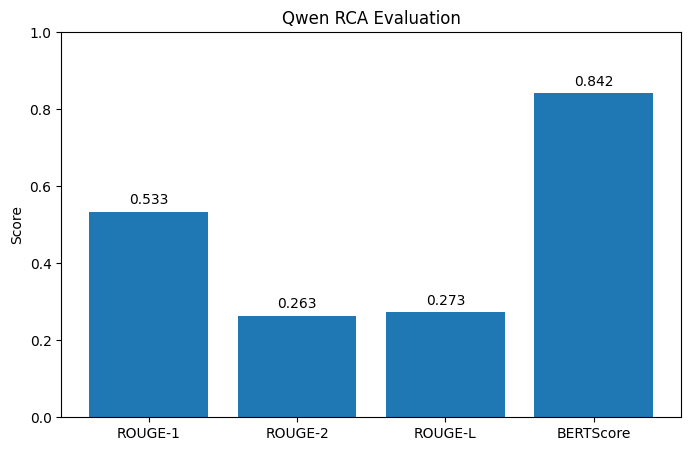

In [34]:
import matplotlib.pyplot as plt

labels = [
    "ROUGE-1",
    "ROUGE-2",
    "ROUGE-L",
    "BERTScore"
]

values = [
    metrics["ROUGE-1"],
    metrics["ROUGE-2"],
    metrics["ROUGE-L"],
    metrics["BERTScore_F1"]
]

plt.figure(figsize=(8,5))

plt.bar(labels, values)

plt.title("Qwen RCA Evaluation")
plt.ylabel("Score")
plt.ylim(0,1)

for i, v in enumerate(values):
    plt.text(i, v + 0.02, str(round(v,3)), ha="center")

plt.show()

In [35]:
from google.colab import files

files.download("rca_metrics.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [36]:
plt.savefig("qwen_rca_evaluation.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [37]:
from google.colab import files
files.download("qwen_rca_evaluation.png")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>